In [738]:
"""
Bus Seat Demand Forecasting Pipeline
predicting bus seat demand using LightGBM.

"""

'\nBus Seat Demand Forecasting Pipeline\npredicting bus seat demand using LightGBM.\n\n'

In [739]:
# !pip3 install lightgbm

In [740]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from scipy import stats

In [741]:
train=pd.read_csv(r"C:\Users\vinod\ML\Redbus Hackathon\train.csv")
df=pd.read_csv(r"C:\Users\vinod\ML\Redbus Hackathon\transactions.csv")
test=pd.read_csv(r"C:\Users\vinod\ML\Redbus Hackathon\test_8gqdJqH.csv")

In [742]:
route_stats = train.groupby(["srcid", "destid"])["final_seatcount"].agg(["mean", "std"]).reset_index()
route_stats.columns = ["srcid", "destid", "route_mean", "route_std"]
train = train.merge(route_stats, on=["srcid", "destid"], how="left")
test = test.merge(route_stats, on=["srcid", "destid"], how="left")

In [743]:
# values1=df['srcid_region'].value_counts()
# values2=df['destid_region'].value_counts()

In [744]:
# labels=values1.index
# plt.figure(figsize=(8,6))
# plt.title("Source Region Value Counts")
# plt.pie(values1,labels=labels,autopct=".%2f")
# plt.show()

In [745]:
# labels2=values2.index
# plt.figure(figsize=(8,6))
# plt.title("Destination Region Value Counts")
# plt.pie(values2,labels=labels2,autopct=".%2f")
# plt.show()

In [746]:
# plt.figure(figsize=(8, 6))
# sns.barplot(x='dbd', y='cumsum_seatcount', data=df)
# plt.title('dbd vs cumsum_seatcount')
# plt.xlabel('dbd')
# plt.ylabel('Final Seatcount')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [747]:
# plt.figure(figsize=(8, 6))
# sns.barplot(x='dbd', y='cumsum_searchcount', data=df)
# plt.title('dbd vs cumsum_searchcount')
# plt.xlabel('dbd')
# plt.ylabel('Final Searchcount')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [748]:
# from ydata_profiling import ProfileReport
# prof=ProfileReport(df,explorative=True)
# prof.to_file(output_file="EDA_Redbus1.html")

In [749]:
train.head(),train.shape

(          doj  srcid  destid  final_seatcount   route_mean    route_std
 0  2023-03-01     45      46           2838.0  4218.648810  1069.316880
 1  2023-03-01     46      45           2298.0  4044.571429  1103.766561
 2  2023-03-01     45      47           2720.0  4022.431548  1128.414758
 3  2023-03-01     47      45           2580.0  4015.877976  1054.536895
 4  2023-03-01     46       9           4185.0  4954.995536  1507.324675,
 (67200, 6))

In [750]:
test.head(),test.shape

(          route_key         doj  srcid  destid   route_mean    route_std
 0  2025-02-11_46_45  2025-02-11     46      45  4044.571429  1103.766561
 1  2025-01-20_17_23  2025-01-20     17      23  1321.897321   389.919087
 2  2025-01-08_02_14  2025-01-08      2      14  1538.325893   680.785677
 3  2025-01-08_08_47  2025-01-08      8      47  1481.488095   616.389071
 4  2025-01-08_09_46  2025-01-08      9      46  4814.683036  1586.108421,
 (5900, 6))

# ?

In [751]:
# test=test.merge(df,on=['doj','srcid','destid'])
# test.describe()

In [752]:
df.head(),df.shape

(          doj         doi  srcid  destid    srcid_region   destid_region  \
 0  2023-03-01  2023-01-30     45      46       Karnataka      Tamil Nadu   
 1  2023-03-01  2023-01-30     46      45      Tamil Nadu       Karnataka   
 2  2023-03-01  2023-01-30     45      47       Karnataka  Andhra Pradesh   
 3  2023-03-01  2023-01-30     47      45  Andhra Pradesh       Karnataka   
 4  2023-03-01  2023-01-30     46       9      Tamil Nadu      Tamil Nadu   
 
   srcid_tier destid_tier  cumsum_seatcount  cumsum_searchcount  dbd  
 0     Tier 1      Tier 1               8.0                76.0   30  
 1     Tier 1      Tier 1               8.0                70.0   30  
 2     Tier 1      Tier 1               4.0               142.0   30  
 3     Tier 1      Tier 1               0.0                68.0   30  
 4     Tier 1       Tier2               9.0               162.0   30  ,
 (2266100, 11))

In [753]:
df['route_key'] = df['doj'].astype(str) + '_' + df['srcid'].astype(str) + '_' + df['destid'].astype(str)
train['route_key'] = train['doj'].astype(str) + '_' + train['srcid'].astype(str) + '_' + train['destid'].astype(str)

In [754]:
df= pd.merge(train,df, on=['route_key','srcid','destid','doj'])
df.shape

(2083200, 15)

In [755]:

df.head()

,doj,srcid,destid,final_seatcount,route_mean,route_std,route_key,doi,srcid_region,destid_region,srcid_tier,destid_tier,cumsum_seatcount,cumsum_searchcount,dbd
0,2023-03-01,45,46,2838.0,4218.64881,1069.31688,2023-03-01_45_46,2023-01-30,Karnataka,Tamil Nadu,Tier 1,Tier 1,8.0,76.0,30
1,2023-03-01,45,46,2838.0,4218.64881,1069.31688,2023-03-01_45_46,2023-01-31,Karnataka,Tamil Nadu,Tier 1,Tier 1,8.0,94.0,29
2,2023-03-01,45,46,2838.0,4218.64881,1069.31688,2023-03-01_45_46,2023-02-01,Karnataka,Tamil Nadu,Tier 1,Tier 1,8.0,108.0,28
3,2023-03-01,45,46,2838.0,4218.64881,1069.31688,2023-03-01_45_46,2023-02-02,Karnataka,Tamil Nadu,Tier 1,Tier 1,8.0,126.0,27
4,2023-03-01,45,46,2838.0,4218.64881,1069.31688,2023-03-01_45_46,2023-02-03,Karnataka,Tamil Nadu,Tier 1,Tier 1,8.0,146.0,26


In [756]:
df["doj"] = pd.to_datetime(df["doj"])
df["doi"] = pd.to_datetime(df["doi"])

df["doj_month"] = df["doj"].dt.month
df["doj_week"] = df["doj"].dt.isocalendar().week.astype(int)
df["doj_day"] = df["doj"].dt.day
df["doj_dayofweek"] = df["doj"].dt.dayofweek
df["is_weekend"] = df["doj_dayofweek"].isin([5, 6]).astype(int)

df.head()

,doj,srcid,destid,final_seatcount,route_mean,route_std,route_key,doi,srcid_region,destid_region,srcid_tier,destid_tier,cumsum_seatcount,cumsum_searchcount,dbd,doj_month,doj_week,doj_day,doj_dayofweek,is_weekend
0,2023-03-01,45,46,2838.0,4218.64881,1069.31688,2023-03-01_45_46,2023-01-30,Karnataka,Tamil Nadu,Tier 1,Tier 1,8.0,76.0,30,3,9,1,2,0
1,2023-03-01,45,46,2838.0,4218.64881,1069.31688,2023-03-01_45_46,2023-01-31,Karnataka,Tamil Nadu,Tier 1,Tier 1,8.0,94.0,29,3,9,1,2,0
2,2023-03-01,45,46,2838.0,4218.64881,1069.31688,2023-03-01_45_46,2023-02-01,Karnataka,Tamil Nadu,Tier 1,Tier 1,8.0,108.0,28,3,9,1,2,0
3,2023-03-01,45,46,2838.0,4218.64881,1069.31688,2023-03-01_45_46,2023-02-02,Karnataka,Tamil Nadu,Tier 1,Tier 1,8.0,126.0,27,3,9,1,2,0
4,2023-03-01,45,46,2838.0,4218.64881,1069.31688,2023-03-01_45_46,2023-02-03,Karnataka,Tamil Nadu,Tier 1,Tier 1,8.0,146.0,26,3,9,1,2,0


In [757]:
df.sample()

,doj,srcid,destid,final_seatcount,route_mean,route_std,route_key,doi,srcid_region,destid_region,srcid_tier,destid_tier,cumsum_seatcount,cumsum_searchcount,dbd,doj_month,doj_week,doj_day,doj_dayofweek,is_weekend
554082,2023-08-26,45,39,1064.0,1634.363095,732.145783,2023-08-26_45_39,2023-08-15,Karnataka,Tamil Nadu,Tier 1,Tier 3,148.0,1328.0,11,8,34,26,5,1


In [758]:
df=df.drop(['doj'],axis=1)

In [759]:
df.sample(5)

,srcid,destid,final_seatcount,route_mean,route_std,route_key,doi,srcid_region,destid_region,srcid_tier,destid_tier,cumsum_seatcount,cumsum_searchcount,dbd,doj_month,doj_week,doj_day,doj_dayofweek,is_weekend
1554950,30,14,1044.0,1563.571429,558.670388,2024-07-14_30_14,2024-07-05,Maharashtra and Goa,Maharashtra and Goa,Tier 1,Tier2,20.0,1880.0,9,7,28,14,6,1
387562,45,47,2798.0,4022.431548,1128.414758,2023-07-04_45_47,2023-06-04,Karnataka,Andhra Pradesh,Tier 1,Tier 1,0.0,46.0,30,7,27,4,1,0
1653516,42,45,1140.0,1683.196429,586.575174,2024-08-15_42_45,2024-07-23,Karnataka,Karnataka,Tier2,Tier 1,12.0,388.0,23,8,33,15,3,0
1031944,33,46,1740.0,1394.635417,863.404592,2024-01-27_33_46,2024-01-13,Tamil Nadu,Tamil Nadu,Tier 3,Tier 1,95.0,980.0,14,1,4,27,5,1
962381,47,2,1305.0,1761.264881,546.453782,2024-01-05_47_2,2023-12-23,Andhra Pradesh,Maharashtra and Goa,Tier 1,Tier 1,20.0,1000.0,13,1,1,5,4,0


# New columns

In [760]:
df['south_region']=np.where(
    (df['srcid_region'].isin(['Tamil Nadu','Maharshtra and Goa','Andhra Pradesh','Karnataka'])) |(df['destid_region'].isin(['Tamil Nadu','Maharshtra and Goa','Andhra Pradesh','Karnataka'])),1,0)

In [761]:
df['srcid_tier'].value_counts()

srcid_tier
Tier 1    1229088
Tier2      645792
Tier 3     124992
Tier 4      83328
Name: count, dtype: int64

In [762]:
for i in range(1,5):
  if(i==2):
    df['srcid_tier']=df['srcid_tier'].replace(f"Tier{i}",i)
    df['destid_tier']=df['destid_tier'].replace(f"Tier{i}",i)
  else:
    df['srcid_tier']=df['srcid_tier'].replace(f"Tier {i}",i)
    df['destid_tier']=df['destid_tier'].replace(f"Tier {i}",i)

In [763]:
df = df.drop(['srcid_region', 'destid_region'], axis=1)

In [764]:
df['focus_city'] = np.where(
    (df['srcid_tier'] > 2) | (df['destid_tier'] > 2),0,1
)

df=df.drop(['srcid_tier','destid_tier'],axis=1)

In [765]:
df['seat_to_search_ratio'] = df['final_seatcount'] / (df['cumsum_searchcount'] + 1e-5)

In [766]:
df['daily_seatcount']=df.groupby('route_key')['cumsum_seatcount'].diff().fillna(0)


In [767]:
df['daily_search_count'] = df.groupby('route_key')['cumsum_searchcount'].diff().fillna(0)

In [768]:
df['dbd_bucket'] = pd.cut(df['dbd'], bins=[0,15, 31], labels=[1,0])


In [769]:
df=df.drop(['doi'],axis=1)

In [770]:
df.sample(5)

,srcid,destid,final_seatcount,route_mean,route_std,route_key,cumsum_seatcount,cumsum_searchcount,dbd,doj_month,doj_week,doj_day,doj_dayofweek,is_weekend,south_region,focus_city,seat_to_search_ratio,daily_seatcount,daily_search_count,dbd_bucket
1505410,28,47,1525.0,1825.565476,711.776325,2024-06-28_28_47,5.0,1450.0,11,6,26,28,4,0,1,0,1.051724,0.0,45.0,1
1937859,5,47,2523.0,2794.839286,1243.288482,2024-11-15_5_47,39.0,1746.0,12,11,46,15,4,0,1,1,1.445017,0.0,48.0,1
403978,7,36,1608.0,1714.154762,798.949220,2023-07-09_7_36,0.0,388.0,13,7,27,9,6,1,0,1,4.144330,0.0,88.0,1
495701,36,22,1105.0,1346.458333,488.995093,2023-08-07_36_22,0.0,465.0,19,8,32,7,0,0,0,1,2.376344,0.0,190.0,0
2075865,45,5,1460.0,1774.471726,635.035511,2024-12-29_45_5,40.0,2020.0,18,12,52,29,6,1,1,1,0.722772,10.0,355.0,0


In [771]:
# df[df['route_key']=='2023-09-07_2_19']


In [772]:
df.groupby('is_weekend')['final_seatcount'].mean()

is_weekend
0    1904.626396
1    2244.487135
Name: final_seatcount, dtype: float64

In [773]:
# plt.figure(figsize=(8, 6))
# sns.barplot(x='date', y='final_seatcount', data=date)
# plt.title('dbd vs cumsum_searchcount')
# plt.xlabel('dbd')
# plt.ylabel('Final Searchcount')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [774]:
df=df[df['dbd']==15]

In [775]:
# encoding route_key

In [776]:
combo_map = {k: i for i, k in enumerate(df["route_key"].unique())}
df["route_key"] = df["route_key"].map(combo_map)

In [777]:
combo_map = {k: i for i, k in enumerate(test["route_key"].unique())}
test["route_key"] = test["route_key"].map(combo_map)

In [778]:
df.head()

,srcid,destid,final_seatcount,route_mean,route_std,route_key,cumsum_seatcount,cumsum_searchcount,dbd,doj_month,doj_week,doj_day,doj_dayofweek,is_weekend,south_region,focus_city,seat_to_search_ratio,daily_seatcount,daily_search_count,dbd_bucket
15,45,46,2838.0,4218.648810,1069.316880,0,16.0,480.0,15,3,9,1,2,0,1,1,5.912500,0.0,32.0,1
46,46,45,2298.0,4044.571429,1103.766561,1,34.0,352.0,15,3,9,1,2,0,1,1,6.528409,2.0,28.0,1
77,45,47,2720.0,4022.431548,1128.414758,2,36.0,892.0,15,3,9,1,2,0,1,1,3.049327,6.0,96.0,1
108,47,45,2580.0,4015.877976,1054.536895,3,18.0,1130.0,15,3,9,1,2,0,1,1,2.283186,0.0,50.0,1
139,46,9,4185.0,4954.995536,1507.324675,4,48.0,1023.0,15,3,9,1,2,0,1,1,4.090909,9.0,147.0,1


C:\Users\vinod\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


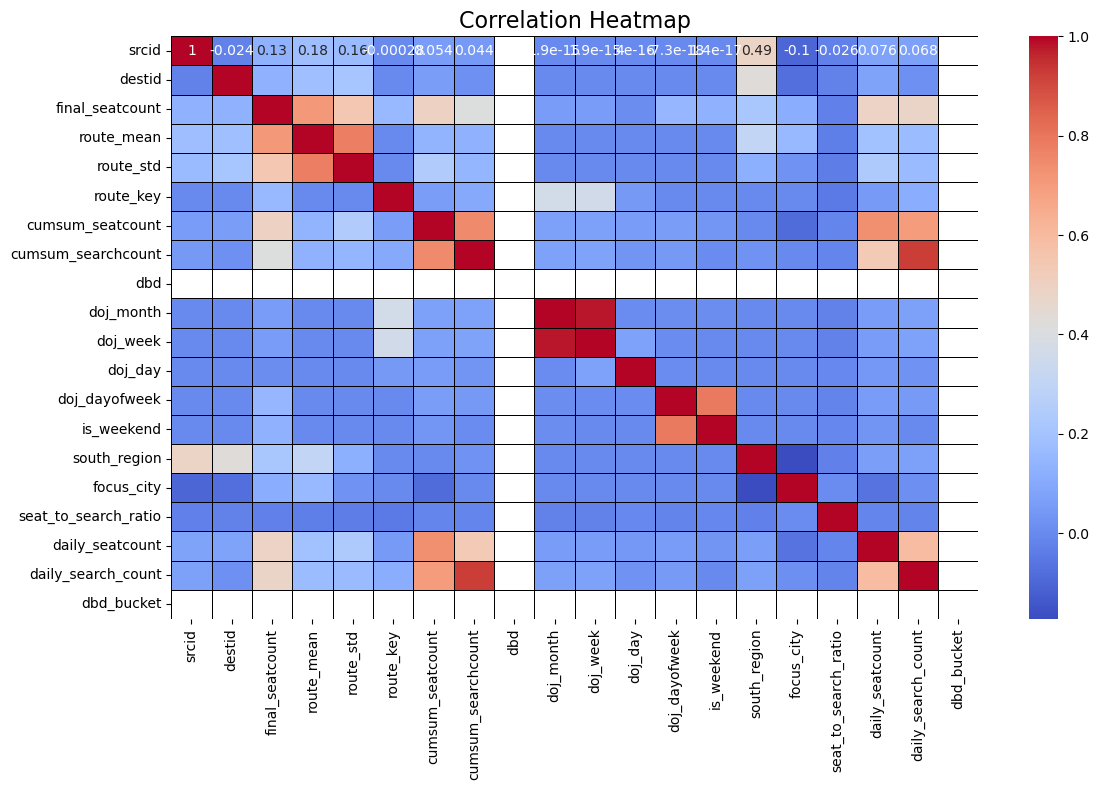

In [779]:
corr = df.corr()

# Set the figure size
plt.figure(figsize=(12, 8))

# Create the heatmap with annotations and color map
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, linecolor='black')

# Add a title
plt.title("Correlation Heatmap", fontsize=16)

# Show the plot
plt.tight_layout()
plt.show()

In [780]:
df.head()

,srcid,destid,final_seatcount,route_mean,route_std,route_key,cumsum_seatcount,cumsum_searchcount,dbd,doj_month,doj_week,doj_day,doj_dayofweek,is_weekend,south_region,focus_city,seat_to_search_ratio,daily_seatcount,daily_search_count,dbd_bucket
15,45,46,2838.0,4218.648810,1069.316880,0,16.0,480.0,15,3,9,1,2,0,1,1,5.912500,0.0,32.0,1
46,46,45,2298.0,4044.571429,1103.766561,1,34.0,352.0,15,3,9,1,2,0,1,1,6.528409,2.0,28.0,1
77,45,47,2720.0,4022.431548,1128.414758,2,36.0,892.0,15,3,9,1,2,0,1,1,3.049327,6.0,96.0,1
108,47,45,2580.0,4015.877976,1054.536895,3,18.0,1130.0,15,3,9,1,2,0,1,1,2.283186,0.0,50.0,1
139,46,9,4185.0,4954.995536,1507.324675,4,48.0,1023.0,15,3,9,1,2,0,1,1,4.090909,9.0,147.0,1


In [781]:
x=df.drop(['seat_to_search_ratio','dbd','final_seatcount','dbd_bucket','doj_month'],axis=1)
y=df['final_seatcount']
x.shape,y.shape

((67200, 15), (67200,))

In [782]:
x

,srcid,destid,route_mean,route_std,route_key,cumsum_seatcount,cumsum_searchcount,doj_week,doj_day,doj_dayofweek,is_weekend,south_region,focus_city,daily_seatcount,daily_search_count
15,45,46,4218.648810,1069.316880,0,16.0,480.0,9,1,2,0,1,1,0.0,32.0
46,46,45,4044.571429,1103.766561,1,34.0,352.0,9,1,2,0,1,1,2.0,28.0
77,45,47,4022.431548,1128.414758,2,36.0,892.0,9,1,2,0,1,1,6.0,96.0
108,47,45,4015.877976,1054.536895,3,18.0,1130.0,9,1,2,0,1,1,0.0,50.0
139,46,9,4954.995536,1507.324675,4,48.0,1023.0,9,1,2,0,1,1,9.0,147.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2083060,2,24,1304.196429,462.184627,67195,20.0,1300.0,1,31,1,0,0,1,0.0,105.0
2083091,44,45,1292.343750,471.400525,67196,75.0,1220.0,1,31,1,0,1,1,0.0,45.0
2083122,47,10,1203.816964,370.168497,67197,15.0,1560.0,1,31,1,0,1,0,0.0,15.0
2083153,38,36,1214.337798,637.978108,67198,0.0,340.0,1,31,1,0,0,1,0.0,60.0


In [783]:
columns=x.columns
columns

Index(['srcid', 'destid', 'route_mean', 'route_std', 'route_key',
       'cumsum_seatcount', 'cumsum_searchcount', 'doj_week', 'doj_day',
       'doj_dayofweek', 'is_weekend', 'south_region', 'focus_city',
       'daily_seatcount', 'daily_search_count'],
      dtype='object')

In [784]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [785]:
x_scaled=scaler.fit_transform(x)
x_scaled

array([[ 0.92681697,  1.01952036,  2.62325807, ...,  0.5       ,
        -0.44364513, -0.29702887],
       [ 0.98680513,  0.95678064,  2.41727408, ...,  0.5       ,
        -0.28920708, -0.30498298],
       [ 0.92681697,  1.08226007,  2.39107618, ...,  0.5       ,
         0.01966902, -0.1697631 ],
       ...,
       [ 1.04679328, -1.23910936, -0.94416173, ..., -2.        ,
        -0.44364513, -0.33083384],
       [ 0.5068999 ,  0.39212321, -0.93171254, ...,  0.5       ,
        -0.44364513, -0.24135009],
       [-0.63287502,  0.01568493, -0.59936129, ...,  0.5       ,
        -0.05755001, -0.10215315]])

In [786]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,random_state=42,test_size=0.2)

In [787]:
x_train

array([[ 0.98680513,  0.95678064,  2.41727408, ...,  0.5       ,
        -0.28920708, -0.08624493],
       [-1.41272102,  1.08226007, -0.67103661, ..., -2.        ,
        -0.44364513, -0.36066176],
       [-1.65267363, -0.67445193, -0.00603478, ...,  0.5       ,
         0.71464025, -0.22146482],
       ...,
       [ 0.98680513,  0.20390407, -0.7227263 , ..., -2.        ,
        -0.44364513, -0.15186635],
       [-1.65267363, -0.67445193, -0.00603478, ...,  0.5       ,
         0.32854512, -0.24135009],
       [-1.65267363, -0.36075336, -0.82538373, ...,  0.5       ,
        -0.44364513, -0.30100592]])

In [788]:
train.head()

,doj,srcid,destid,final_seatcount,route_mean,route_std,route_key
0,2023-03-01,45,46,2838.0,4218.648810,1069.316880,2023-03-01_45_46
1,2023-03-01,46,45,2298.0,4044.571429,1103.766561,2023-03-01_46_45
2,2023-03-01,45,47,2720.0,4022.431548,1128.414758,2023-03-01_45_47
3,2023-03-01,47,45,2580.0,4015.877976,1054.536895,2023-03-01_47_45
4,2023-03-01,46,9,4185.0,4954.995536,1507.324675,2023-03-01_46_9


In [843]:
def train_model(X_train, y_train, X_val, y_val):
    """Train LightGBM model with early stopping"""
    print("\nTraining model...")
    
    model = LGBMRegressor(
        learning_rate=0.05,
        max_depth=20,
        num_leaves=31,
        feature_fraction=0.7,
        bagging_fraction=0.8,
        bagging_freq=5,
        n_estimators=1000,
        random_state=13,
        force_col_wise=True  # Suppress warning
    )
    
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            early_stopping(stopping_rounds=100),
            log_evaluation(period=100)
        ]
    )
    
    return model

In [844]:
def evaluate_model(model, X_val, y_val):
    """Evaluate model performance and generate diagnostics"""
    print("\nEvaluating model...")
    
    # Generate predictions
    val_preds = model.predict(X_val)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    mae = mean_absolute_error(y_val, val_preds)
    r2 = r2_score(y_val, val_preds)
    
    print(f"\nValidation Metrics:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    
    # Plot feature importance
    plt.figure(figsize=(10, 8))
    feat_imp = pd.Series(model.feature_importances_, index=columns)
    feat_imp.nlargest(15).sort_values().plot(kind='barh')
    plt.title('Top 15 Feature Importances')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()
    
    # Plot actual vs predicted
    plt.figure(figsize=(10, 6))
    sns.regplot(x=y_val, y=val_preds, scatter_kws={'alpha':0.3})
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted Values')
    plt.tight_layout()
    plt.savefig('actual_vs_predicted.png')
    plt.show()
    
    # Plot error distribution
    errors = y_val - val_preds
    plt.figure(figsize=(10, 6))
    sns.histplot(errors, kde=True)
    plt.xlabel('Prediction Error')
    plt.title('Error Distribution')
    plt.tight_layout()
    plt.savefig('error_distribution.png')
    plt.show()

In [845]:
model=train_model(x_train,y_train,x_test,y_test)


Training model...
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Info] Total Bins 1509
[LightGBM] [Info] Number of data points in the train set: 53760, number of used features: 15
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fra


Evaluating model...
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5

Validation Metrics:
RMSE: 335.0837
MAE: 241.0547
R²: 0.9220


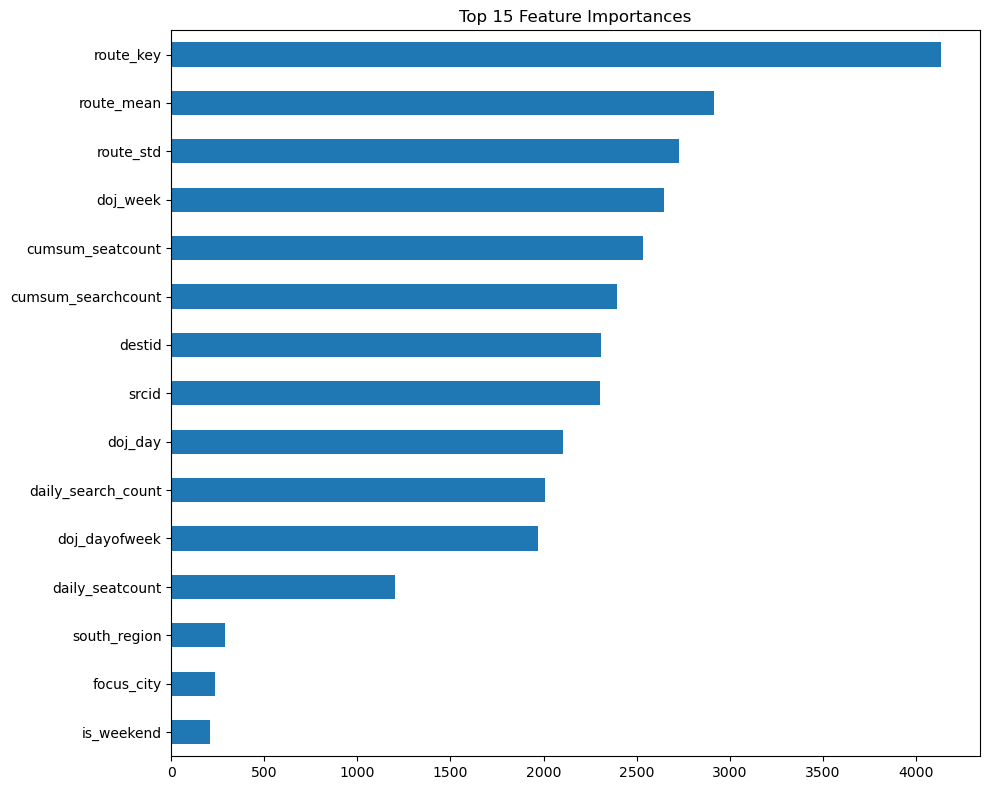

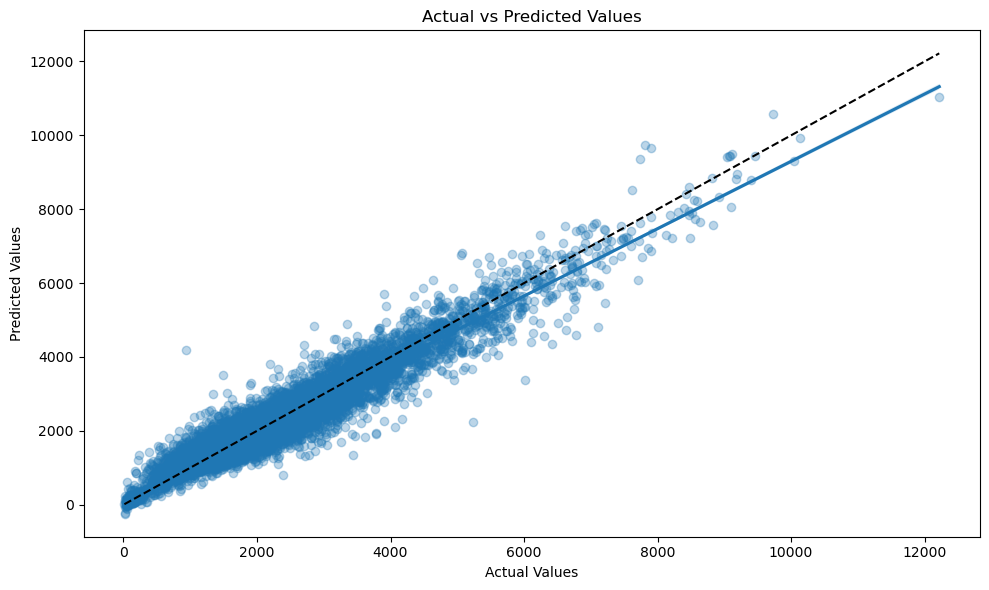

C:\Users\vinod\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


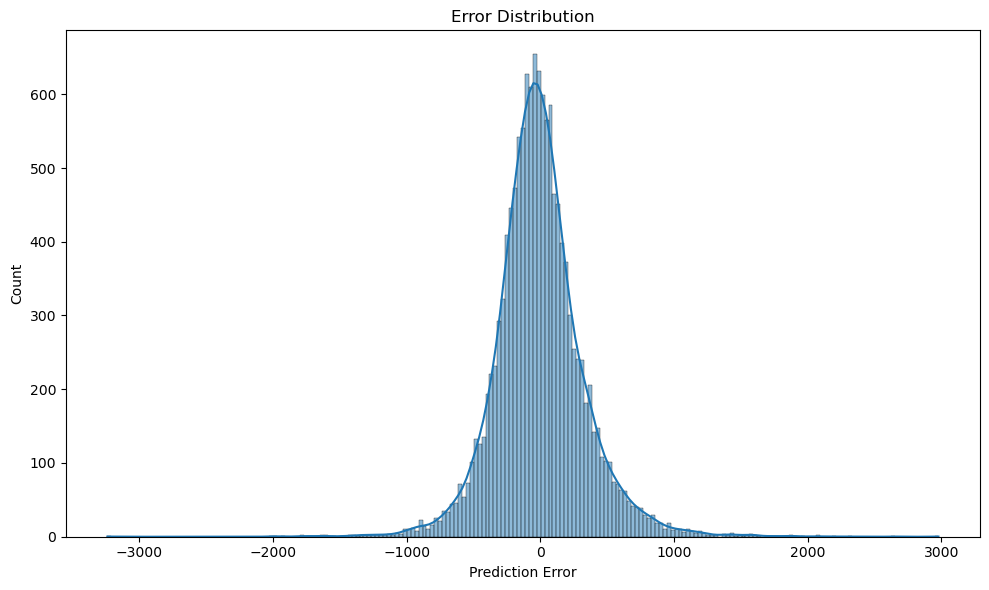

In [846]:
evaluate_model(model,x_test,y_test)

In [847]:
# def prepare_test_data(X_test, X_train, encoders):
#     """Prepare test data for prediction"""
#     print("\nPreparing test data...")
    
#     X_test = X_test.fillna(0)
    
#     # Encode categoricals
#     for col in X_test.select_dtypes(include=["object"]).columns:
#         if col in encoders:
#             le = encoders[col]
#             X_test[col] = le.transform(X_test[col].astype(str))
#         else:
#             X_test[col] = LabelEncoder().fit_transform(X_test[col].astype(str))
    
#     # Align columns
#     missing_cols = set(X_train.columns) - set(X_test.columns)
#     for col in missing_cols:
#         X_test[col] = 0
#     X_test = X_test[X_train.columns]
    
#     return X_test